# 🎯 Master Multi-Asset Trainer (Quant Factory Edition)

Notebook ini adalah **Pabrik Model AI** profesional yang menggabungkan basis kuat dari `AI Trading Advanced V2` dengan sistem visualisasi *Quant-Level*.

### Fitur Unggulan:
1. **Zero-Data Assumption**: Secara otomatis mendownload data dari exchange jika file CSV belum tersedia atau tidak valid.
2. **High-Precision Metrics**: Menghapus format scientific (e-05) agar lu gampang baca loss & error.
3. **Advanced Quant Plot**: Visualisasi dual-subplot dengan *Shaded Error Area* dan *Gap Delta Bar*.
4. **Factory Logic**: Narik data otomatis, training otomatis, dan evaluasi dalam satu klik.
5. **Huber Architecture**: Lebih kebal terhadap 'fake pump/dump' dibanding model biasa.

In [62]:
# === KONFIGURASI PABRIK ===
COIN = 'SOL'           # Pilihan: BTC, ETH, SOL
TIMEFRAME = '5'      # Pilihan: 1h, 5
WINDOW_SIZE = 60      # Lookback 60 periode
FETCH_DATA = False    # Set True jika ingin FORCE download data baru meskipun file sudah ada

print(f"Factory Mode: Mempersiapkan Model {COIN} ({TIMEFRAME})")

Factory Mode: Mempersiapkan Model SOL (5)


In [63]:
!pip install matplotlib ta


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import ccxt
import joblib
import os
import time
from datetime import datetime
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
import warnings

warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__} | GPU: {tf.config.list_physical_devices('GPU')}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
TensorFlow: 2.21.0 | GPU: []


## 1. Data Acquisition with Safety Validation

In [64]:
def fetch_historical_data(symbol, timeframe):
    exchange = ccxt.indodax()
    now = exchange.milliseconds()
    # 1H -> 5 Tahun, 5M -> 6 Bulan
    days = 365 * 5 if timeframe == '1h' else 30 * 6
    since = now - (days * 24 * 60 * 60 * 1000)
    
    all_ohlcv = []
    current_since = since
    print(f"Memulai penarikan data {symbol} ({timeframe}) untuk {days} hari...")
    
    while current_since < now:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=current_since, limit=1000)
            if not ohlcv: break
            
            all_ohlcv.extend(ohlcv)
            current_since = ohlcv[-1][0] + 1
            
            prog = min(100, ((current_since - since) / (now - since)) * 100)
            print(f"\rProgres: {prog:.2f}% | Data: {len(all_ohlcv)}", end='')
            time.sleep(exchange.rateLimit / 1000)
            
            if (now - current_since) < (60 * 1000 * 60): break
        except: 
            time.sleep(2); continue
            
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    return df

def ensure_data(coin, timeframe, force_fetch=False):
    fname = f"{coin.lower()}_idr_{timeframe}_data.csv"
    
    # Safety Check: Validasi jika file sudah ada dan layak pakai
    if not force_fetch and os.path.exists(fname):
        try:
            df = pd.read_csv(fname)
            required_cols = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
            if all(col in df.columns for col in required_cols) and len(df) > 1000:
                print(f"Data '{fname}' sudah tersedia secara lokal ({len(df)} baris). Skip penarikan.")
                return df
            else:
                print(f"Data '{fname}' tidak valid. Menarik ulang...")
        except:
            print(f"Gagal membaca '{fname}'. Menarik ulang...")

    # Tarik data dari Indodax
    df = fetch_historical_data(f"{coin}/IDR", timeframe)
    df.to_csv(fname, index=False)
    print(f"\nData {coin} berhasil disimpan ke {fname}")
    return df

# --- Eksekusi Penarikan Data ---
df_target = ensure_data(COIN, TIMEFRAME, force_fetch=FETCH_DATA)

if COIN != 'BTC':
    df_btc = ensure_data('BTC', TIMEFRAME, force_fetch=FETCH_DATA)
    df_btc = df_btc[['timestamp', 'close', 'volume']].rename(columns={'close': 'btc_close', 'volume': 'btc_volume'})
    df_target = pd.merge(df_target, df_btc, on='timestamp', how='inner')
    print("Korelasi BTC digabungkan.")

Memulai penarikan data SOL/IDR (5) untuk 180 hari...
Progres: 100.00% | Data: 51840
Data SOL berhasil disimpan ke sol_idr_5_data.csv
Data 'btc_idr_5_data.csv' sudah tersedia secara lokal (51841 baris). Skip penarikan.
Korelasi BTC digabungkan.


## 2. Feature Engineering & Multi-Variate Logic

In [65]:
def add_technical_indicators(df):
    df['vol_sma9'] = df['volume'].rolling(window=9).mean()
    df['rsi'] = RSIIndicator(close=df['close']).rsi()
    df['macd'] = MACD(close=df['close']).macd()
    df['atr'] = AverageTrueRange(high=df['high'], low=df['low'], close=df['close']).average_true_range()
    bb = BollingerBands(close=df['close'])
    df['bb_h'] = bb.bollinger_hband(); df['bb_l'] = bb.bollinger_lband()
    df['obv'] = OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
    return df.dropna()

df_final = add_technical_indicators(df_target)
features = ['open', 'high', 'low', 'close', 'volume', 'vol_sma9', 'rsi', 'macd', 'atr', 'bb_h', 'bb_l', 'obv']
if 'btc_close' in df_final.columns: features += ['btc_close', 'btc_volume']
print(f"Total Fitur Input: {len(features)}")

Total Fitur Input: 14


## 3. Preprocessing (90/10 Split)

In [66]:
scaler_x = MinMaxScaler(); scaler_y = MinMaxScaler()
scaled_x = scaler_x.fit_transform(df_final[features])
scaled_y = scaler_y.fit_transform(df_final[['close']])

X, y = [], []
for i in range(len(scaled_x) - WINDOW_SIZE):
    X.append(scaled_x[i : i + WINDOW_SIZE])
    y.append(scaled_y[i + WINDOW_SIZE])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 4. Arsitektur Model Sniper (V2 Base)

In [67]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    att = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = LayerNormalization()(Add()([x, att]))
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs, out)
    model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
    return model

model = build_model((WINDOW_SIZE, len(features)))
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 60, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 60, 64)    │      2,752 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 30, 64)    │          0 │ conv1d_10[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 30, 128)   │     24,704 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ (None, 30, 128)   │    131,584 │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 128)   │          0 │ lstm_10[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ (None, 30, 64)    │     49,408 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ lstm_11[0][0],    │
│ (MultiHeadAttentio… │                   │            │ lstm_11[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 64)    │          0 │ lstm_11[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         33 │ dense_10[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,057 (1.06 MB)

 Trainable params: 277,057 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training dengan Metrics

In [68]:
class ReadableProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        l = logs.get('loss'); vl = logs.get('val_loss'); m = logs.get('mae')
        print(f"\rEpoch {epoch+1:03d} | Loss: {l:.7f} | Val Loss: {vl:.7f} | MAE: {m:.5f}", end="")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
    ReadableProgress()
]
print("Training Factory Started...")
model.fit(X_train, y_train, validation_split=0.1, epochs=60, batch_size=64, callbacks=callbacks, verbose=0)
print("\nTraining Selesai!")

Training Factory Started...
Epoch 060 | Loss: 0.0000096 | Val Loss: 0.0000054 | MAE: 0.00315
Training Selesai!


## 6. Quant-Level Evaluation Tool


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- FINAL ACCURACY --- 
MAPE Accuracy: 0.81% | Directional: 42.93% | MAE: Rp 9,756


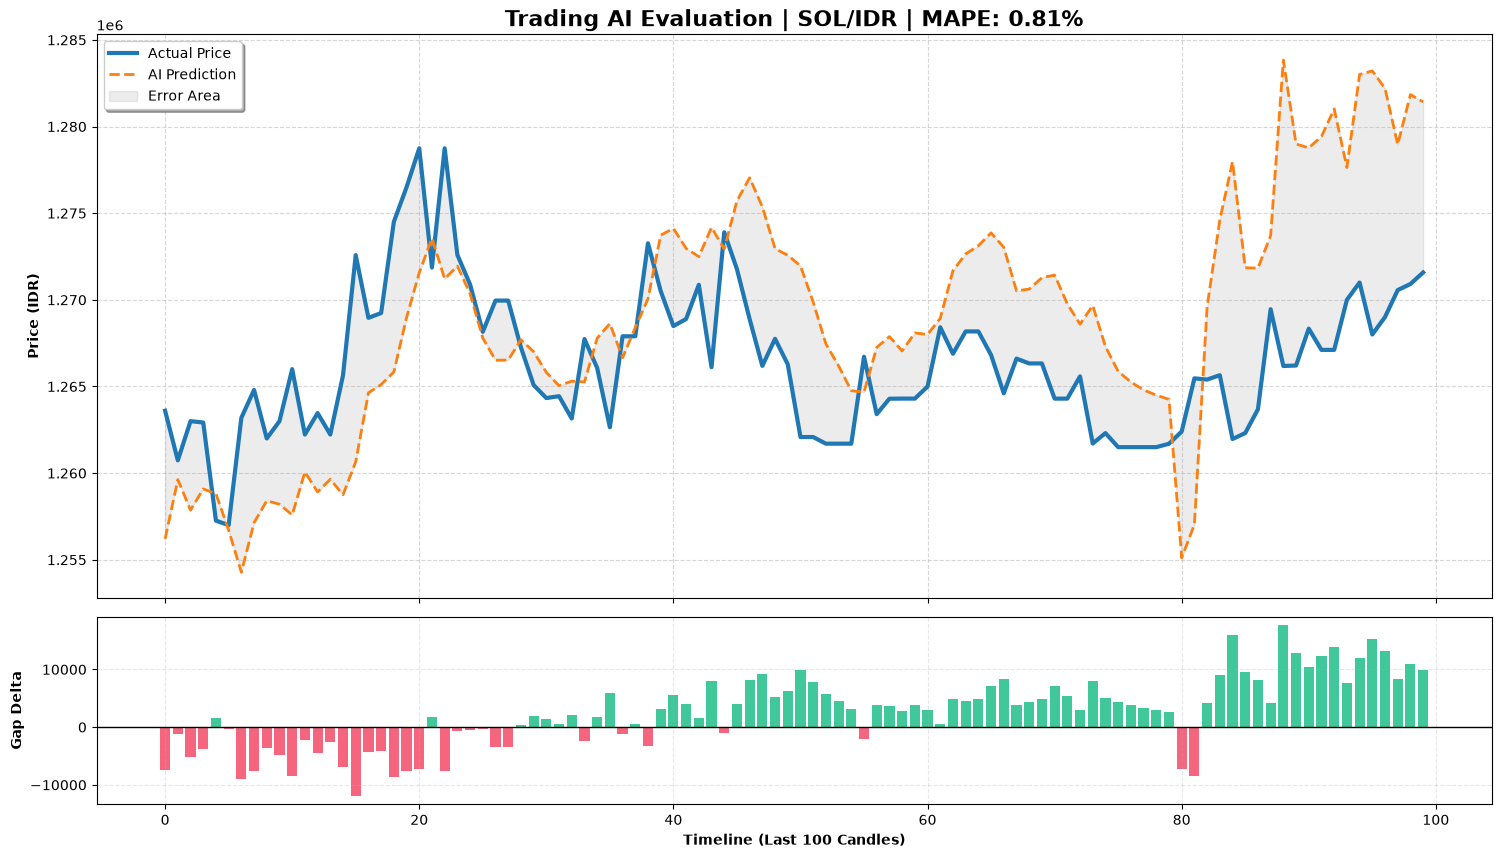


--- TABEL PERBANDINGAN 10 DATA TERAKHIR ---


,Real,AI,Gap,Error %
90,"1,268,340","1,278,770","+10,430",0.82%
91,"1,267,113","1,279,430","+12,318",0.97%
92,"1,267,112","1,281,018","+13,906",1.10%
93,"1,269,999","1,277,640","+7,641",0.60%
94,"1,271,000","1,283,006","+12,006",0.94%
95,"1,268,002","1,283,214","+15,212",1.20%
96,"1,269,007","1,282,200","+13,194",1.04%
97,"1,270,564","1,278,966","+8,402",0.66%
98,"1,270,915","1,281,842","+10,927",0.86%
99,"1,271,579","1,281,424","+9,844",0.77%


In [69]:
!pip install jinja2

#  Prediksi pada data test
y_p_scaled = model.predict(X_test)

# GUNAKAN scaler_y (Sesuai nama variabel di sel Preprocessing)
y_p = scaler_y.inverse_transform(y_p_scaled)
y_t = scaler_y.inverse_transform(y_test)

# 2. Hitung Metrik
mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100
mae = mean_absolute_error(y_t, y_p)

# Akurasi Arah (Directional Accuracy)
true_diff = np.diff(y_t.flatten())
pred_diff = np.diff(y_p.flatten())
da = np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100

print(f"\n--- FINAL ACCURACY --- ")
print(f"MAPE Accuracy: {mape:.2f}% | Directional: {da:.2f}% | MAE: Rp {mae:,.0f}")

# 3. Advanced Quant Plot (Last 100 Candles)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), height_ratios=[3, 1], sharex=True)
plt.subplots_adjust(hspace=0.05)

indices = np.arange(100)
real = y_t[-100:].flatten()
pred = y_p[-100:].flatten()
gaps = pred - real

# Subplot 1: Price & Shaded Error Area
ax1.plot(indices, real, label='Actual Price', color='#1f77b4', linewidth=3)
ax1.plot(indices, pred, label='AI Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
ax1.fill_between(indices, real, pred, color='gray', alpha=0.15, label='Error Area')
ax1.set_title(f"Trading AI Evaluation | {COIN}/IDR | MAPE: {mape:.2f}%", fontsize=16, fontweight='bold')
ax1.set_ylabel("Price (IDR)", fontweight='bold')
ax1.legend(loc='upper left', shadow=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Gap Delta Bar (Hijau = Tebakan di atas Market, Merah = Di bawah)
colors = ['#10b981' if g >= 0 else '#f43f5e' for g in gaps]
ax2.bar(indices, gaps, color=colors, alpha=0.8, label='Gap (Predict - Actual)')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Gap Delta", fontweight='bold')
ax2.set_xlabel("Timeline (Last 100 Candles)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Tabel Perbandingan 10 Data Terakhir
gap_df = pd.DataFrame({'Real': real, 'AI': pred, 'Gap': gaps})
gap_df['Error %'] = (np.abs(gaps) / real) * 100
print("\n--- TABEL PERBANDINGAN 10 DATA TERAKHIR ---")
display(gap_df.tail(10).style.format({
    'Real': '{:,.0f}', 
    'AI': '{:,.0f}', 
    'Gap': '{:+,.0f}', 
    'Error %': '{:.2f}%'
}))

## 7. Save Models

In [70]:
os.makedirs('models', exist_ok=True)

# Standarisasi Suffix: 1h -> 1h, 5m -> 5 (Sesuai ModelManager)
TF_SUFFIX = '1h' if TIMEFRAME == '1h' else '5'
m_name = f"models/{COIN.upper()}_{TF_SUFFIX}.keras"
s_x_name = f"models/{COIN.upper()}_{TF_SUFFIX}_scaler_x.pkl"
s_y_name = f"models/{COIN.upper()}_{TF_SUFFIX}_scaler_y.pkl"

model.save(m_name)
joblib.dump(scaler_x, s_x_name)
joblib.dump(scaler_y, s_y_name)
print(f"Berhasil simpan: {m_name}")

Berhasil simpan: models/SOL_5.keras


In [71]:
# === CELL DOKUMENTASI OTOMATIS ===
import os
from datetime import datetime

 # 1. Setup Direktori
DOCS_DIR = 'training_docs'
os.makedirs(DOCS_DIR, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M')
doc_filename = f"{DOCS_DIR}/{COIN.upper()}_{TIMEFRAME}_{timestamp}.md"
img_filename = f"{DOCS_DIR}/{COIN.upper()}_{TIMEFRAME}_{timestamp}_plot.png"

 # 2. Simpan Grafik Evaluasi Terakhir
 # (Pastikan variabel 'fig' dari sel evaluasi masih ada)
try:
    fig.savefig(img_filename, dpi=300, bbox_inches='tight')
    print(f"Grafik disimpan ke: {img_filename}")
except NameError:
    print("Warning: Variabel 'fig' tidak ditemukan. Pastikan sel evaluasi sudah dijalankan.")
# 3. Generate Konten Markdown
# (Variabel mape, da, mae, features berasal dari sel-sel sebelumnya)
md_content = f"""# Training Report: {COIN.upper()}/{TIMEFRAME}
**Generated on:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
---
## Model Performance
- **MAPE Accuracy:** {mape:.2f}%
- **Directional Accuracy:** {da:.2f}%
- **Mean Absolute Error (MAE):** Rp {mae:,.0f}
## Model Architecture
- **Window Size (Lookback):** {WINDOW_SIZE} periods
- **Total Features:** {len(features)}
- **Features Used:** `{", ".join(features)}`
- **Architecture Base:** Sniper V2 (Conv1D + LSTM + Multi-Head Attention)
## Visual Evaluation
![Training Plot](./{os.path.basename(img_filename)})
---
*Zenith Singularity - Autonomous Trading Ecosystem*
"""
# 4. Tulis ke File Markdown
with open(doc_filename, 'w') as f:
    f.write(md_content)
print(f"Dokumentasi berhasil dibuat: {doc_filename}")

Grafik disimpan ke: training_docs/SOL_5_20260615_1505_plot.png
Dokumentasi berhasil dibuat: training_docs/SOL_5_20260615_1505.md
